In [17]:
import unittest
import sys
import os
import copy
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
print(sys.version)
print(sys.executable)


label_dict  = {}
label_dict['huber_value'] = r"Huber $\mathcal{H}$"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['stem_hydraulic_capacitance_res'] = r"$\Gamma_\mathrm{Stem_{res}}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['d_50_close'] = r"$d_{Leaf, close}$"
label_dict['alpha'] = r"$\alpha$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['gam_stem_div_g0'] = r"$\frac{g_0}{\Gamma_\mathrm{Stem}}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['p50-p88'] =  r"$\psi_{50} - \psi_{88} $"
label_dict['g0_div_gam_stem_x_H'] =  r"g0_div_gam_stem_x_H"
label_dict['g0_div_gam_stem_x_H'] =  r"g0_div_gam_stem_x_H"
label_dict['k_soil_sat0'] =  r"k_soil_sat"
label_dict['root_area_index'] =  r"RAI"
label_dict['psi_tlp'] = r'$\psi_\mathrm{tlp}$'
label_dict['g_stem_res'] = r'$g_\mathrm{stem,res}$'


unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['stem_hydraulic_capacitance_res'] = "kg m-3 MPa-1"
unit_dict['leaf_hydraulic_capacitance'] = "kg m-2 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "-"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['psi88_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g1'] = "-"
unit_dict['g_stem_res'] = "mol m-1 s-1"
unit_dict['psi_leaf_50_close'] = r"MPa"
unit_dict['d_50_close'] = "-"
unit_dict['alpha'] = r"-"
unit_dict['gam_stem_x_H'] = r"-"
unit_dict['gam_stem_div_g0'] = r"-"
unit_dict['k_xyl_x_H'] =r"-"
unit_dict['g_min_loss'] = r"-"
unit_dict['wcont_sigma_deviation'] = r"-"
unit_dict['p50-p88'] =  "MPa"
unit_dict['psi_tlp'] =  "MPa"
unit_dict['g0_div_gam_stem_x_H'] =  "-"
unit_dict['pore_0'] =  "-"
unit_dict['k_soil_sat0'] =  "m s-1"
unit_dict['root_area_index'] =  "m2 m-2"
unit_dict['g_stem_res'] = r's'


sys.path.append("/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone")
from src.contrib.swiss_tree_parser import SwissTreeParser
from src.contrib.auxil.setups import Setup
from src.contrib.auxil.output_df import create_output_df
from src.contrib.auxil.files import get_trees_psi_leaf_folder_path_cc
from src.contrib.config import Config, Swiss_soil_water_input_type

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2025_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_h_kxylem"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "19_ex_con_2025_full_logit_mean_one"

scenario_name = "23_ex_con_2025_full_logit_mean_one_wcont"
scenario_name = "29_ex_con_2025_full_logit_mean_one_wcont_TLP"

rt_output_save_dir = ""
scenario_name = "45_LHS_TLP"
#scenario_name = "46_LHS_no_TLP"
nmax = 1000
N_BEST = 50
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

setup = Setup()
setup.Apply_default_swiss(Swiss_soil_water_input_type.OneLayer_Mean_One_Std)
setup.Apply_default_paths(root_output_directory, scenario_name)
setup.config.parameters_list_file = os.path.join(setup.config.post_path, "parameters_best_mean_alive.csv")
setup.config.config_file = os.path.join("config_dummy.txt")
# Specifying forcing and evalution data paths
#setup.Export()

pdir = os.path.join(post_path, "fig3")
os.makedirs(pdir, exist_ok=True)
# Read in the Swiss trees
tree_parser = SwissTreeParser(get_trees_psi_leaf_folder_path_cc())

print(setup.config.build_folder)

3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:21:13) [GCC 13.3.0]
/Net/Groups/BSI/work_scratch/ppapastefanou/envs/SimPHony_intel_mpich/bin/python
/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone/src/contrib/auxil/../../../build


In [18]:

critical_value = -6


var_additionals = ['wcont_sigma_deviation',
 'psi_leaf_50_close',
 'p50-p88',
 'k_xylem_sat','huber_value',
 'stem_hydraulic_capacitance',
 
 'stem_hydraulic_capacitance_res']

arr = np.full((4,len(var_additionals), 4), '', dtype=object)

ti = 0
for tree_id in [1,2,4,5]: 
    vara_i = 0
    for vara in var_additionals:
        ref_id = 2
        df = pd.read_csv(os.path.join(pdir, f"data_1000_{tree_id}_{ref_id}_{vara}.csv"))
        df['date'] = pd.to_datetime(df['date'])
        df.set_index(df['date'], inplace=True)
        ref_date = df[df['psiLeaf'] < critical_value].index.min()

        ind_ids = [0,1,2,3]

        for id in ind_ids:
            
            id_file = id
            if id > 1:
                id_file = id +1
            
            df = pd.read_csv(os.path.join(pdir, f"data_1000_{tree_id}_{id_file}_{vara}.csv"))
            df['date'] = pd.to_datetime(df['date'])
            df.set_index(df['date'], inplace=True)
            ind_date = df[df['psiLeaf'] < critical_value].index.min()
            if pd.isna(ind_date):
                arr[ti, vara_i, id] = ''
            else:
                diff_days = (ind_date - ref_date).days
                arr[ti, vara_i, id] = str(diff_days)
        vara_i+=1
    ti+=1

In [19]:
arr.shape

(4, 7, 4)

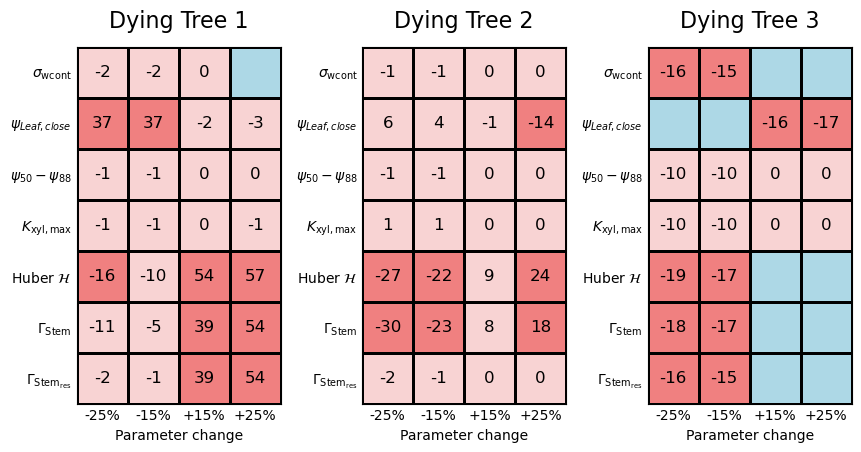

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd

# --- CLEAN + CLASSIFY -------------------------------------------------------

# Strip whitespace safely
arr_clean = np.vectorize(lambda x: str(x).strip())(arr)

# Convert to numeric (non-numbers → NaN)
num = pd.to_numeric(arr_clean.reshape(-1), errors='coerce').reshape(arr.shape)

# Initialize class grid: 0 empty, 1 mild, 2 strong
val_grid = np.zeros(arr.shape, dtype=int)

valid = ~np.isnan(num)
val_grid[valid & (np.abs(num) < 14)]  = 1
val_grid[valid & (np.abs(num) >= 14)] = 2

# --- PLOT -------------------------------------------------------------------

cmap = ListedColormap([
    'lightblue',   # 0 → empty
    '#f8d3d3',     # 1 → light red
    'lightcoral'   # 2 → dark red
])

u = 3
fig = plt.figure(figsize=(10, 6))

for k in [1,2,3]:
    ax = fig.add_subplot(1, u, k)

    rows, cols = arr_clean[k].shape

    # 0/1/2 -> blue/light red/dark red
    ax.pcolormesh(
        val_grid[k], cmap=cmap, vmin=0, vmax=2,
        edgecolors='k', linewidth=1,
        shading='nearest', antialiased=False
    )

    # centered text (now aligns perfectly)
    for i in range(rows):
        for j in range(cols):
            cell = str(arr[k, i, j]).strip()
            if cell:
                ax.text(j , i , cell,
                        ha='center', va='center', fontsize=12, color='black',
                        clip_on=True)

    ax.set_aspect('equal')

    # Centered ticks
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))

    x_labels = ['-25%', '-15%', '+15%', '+25%'][:cols]
    y_labels = [label_dict[lab] for lab in var_additionals][:rows]

    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    ax.tick_params(length=0)

    ax.set_xlim(-0.5, cols-0.5)
    ax.set_ylim(-0.5 +rows,- 0.5) # flip y-axis so first row appears top
    ax.set_title(f"Dying Tree {k}", fontsize=16, pad=14)
    ax.set_xlabel("Parameter change")

plt.subplots_adjust(wspace=0.4)
plt.savefig(os.path.join(post_path, "Figure4.png"), dpi = 300)
plt.show()


In [103]:
cols

4